In [56]:
# 1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set this to the folder in your Drive where the dataset is stored
DRIVE_DATA_PATH = '/content/drive/MyDrive/Fault Localization/datasets/concatfile_SORTED.xlsx'
DRIVE_SAVE_PATH = '/content/drive/MyDrive/Fault Localization/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# 2 Install and import libraries
import numpy as np
import pandas as pd
import os
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("All libraries loaded.")


TensorFlow version: 2.19.0
All libraries loaded.


In [58]:
# 3 Load the Real Dataset from Drive
df_raw = pd.read_excel(DRIVE_DATA_PATH)
print("Shape of raw data:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head(3)

Shape of raw data: (15669, 79)
Columns: ['Time', 'Status', 'Ppv(W)', 'INVTemp(℃)', 'AMTemp1(℃)', 'BTTemp(℃)', 'OUTTemp(℃)', 'AMTemp2(℃)', 'Vstr1(V)', 'Vstr2(V)', 'Vstr3(V)', 'Vstr4(V)', 'Vstr5(V)', 'Vstr6(V)', 'Vstr7(V)', 'Vstr8(V)', 'Vstr9(V)', 'Vstr10(V)', 'Vstr11(V)', 'Vstr12(V)', 'Vstr13(V)', 'Vstr14(V)', 'Vstr15(V)', 'Vstr16(V)', 'Vstr17(V)', 'Vstr18(V)', 'Vstr19(V)', 'Vstr20(V)', 'Vstr21(V)', 'Vstr22(V)', 'Vstr23(V)', 'Vstr24(V)', 'Vstr25(V)', 'Vstr26(V)', 'Vstr27(V)', 'Vstr28(V)', 'Vstr29(V)', 'Vstr30(V)', 'Vstr31(V)', 'Vstr32(V)', 'Istr1(A)', 'Istr2(A)', 'Istr3(A)', 'Istr4(A)', 'Istr5(A)', 'Istr6(A)', 'Istr7(A)', 'Istr8(A)', 'Istr9(A)', 'Istr10(A)', 'Istr11(A)', 'Istr12(A)', 'Istr13(A)', 'Istr14(A)', 'Istr15(A)', 'Istr16(A)', 'Istr17(A)', 'Istr18(A)', 'Istr19(A)', 'Istr20(A)', 'Istr21(A)', 'Istr22(A)', 'Istr23(A)', 'Istr24(A)', 'Istr25(A)', 'Istr26(A)', 'Istr27(A)', 'Istr28(A)', 'Istr29(A)', 'Istr30(A)', 'Istr31(A)', 'Istr32(A)', 'FaultCode', 'FaultBit', 'Subcode(fault/warn)', 

,Time,Status,Ppv(W),INVTemp(℃),AMTemp1(℃),BTTemp(℃),OUTTemp(℃),AMTemp2(℃),Vstr1(V),Vstr2(V),...,Istr30(A),Istr31(A),Istr32(A),FaultCode,FaultBit,Subcode(fault/warn),WarnCode,StrUnmatch,StrUnblance,StrBreak
0,2025-10-30 06:01:01,Normal,222.6,29.1,51.8,29.1,0,0,500.9,500.9,...,0,0,0,0,0,0/0,0,0,0,0
1,2025-10-30 06:06:02,Normal,378.5,30.6,52.1,30.2,0,0,486.6,486.6,...,0,0,0,0,0,0/0,0,0,0,0
2,2025-10-30 06:11:02,Normal,540.5,31.6,52.8,31.5,0,0,505.4,505.4,...,0,0,0,0,0,0/0,0,0,0,0


In [59]:
# 4 Inspect and clean the dataset
# Voltage and current column names for 32 strings
V_COLS = [f'Vstr{i}(V)' for i in range(1, 33)]
I_COLS = [f'Istr{i}(A)' for i in range(1, 33)]
META_COLS = ['Ppv(W)', 'INVTemp(℃)', 'AMTemp1(℃)', 'BTTemp(℃)', 'OUTTemp(℃)', 'AMTemp2(℃)']

ALL_FEATURE_COLS = V_COLS + I_COLS + META_COLS

# Keep only rows where Status is Normal (this is the clean baseline)
df_clean = df_raw[df_raw['Status'] == 'Normal'].copy()
df_clean = df_clean[ALL_FEATURE_COLS].reset_index(drop=True)

# Drop rows with all-zero V and I (night time / inactive periods)
df_clean = df_clean[(df_clean[V_COLS].sum(axis=1) > 0)].reset_index(drop=True)

# Fill any remaining NaN with column mean
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

print("Clean daytime rows:", len(df_clean))
df_clean.describe()

Clean daytime rows: 14424


,Vstr1(V),Vstr2(V),Vstr3(V),Vstr4(V),Vstr5(V),Vstr6(V),Vstr7(V),Vstr8(V),Vstr9(V),Vstr10(V),...,Istr29(A),Istr30(A),Istr31(A),Istr32(A),Ppv(W),INVTemp(℃),AMTemp1(℃),BTTemp(℃),OUTTemp(℃),AMTemp2(℃)
count,14424.000000,14424.000000,14424.000000,14424.000000,14424.000000,14424.000000,14424.000000,14424.000000,14424.0,14424.0,...,14424.0,14424.0,14424.0,14424.0,14424.000000,14424.000000,14424.000000,14424.000000,14424.0,14424.0
mean,558.270362,558.270362,436.432481,436.432481,547.507238,547.507238,560.234768,560.234768,0.0,0.0,...,0.0,0.0,0.0,0.0,12629.511197,59.381330,70.953640,57.115107,0.0,0.0
std,49.759799,49.759799,56.432892,56.432892,70.015992,70.015992,76.606482,76.606482,0.0,0.0,...,0.0,0.0,0.0,0.0,9905.107950,10.811944,7.905388,9.877718,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,33.400000,23.800000,48.100000,24.300000,0.0,0.0
25%,550.300000,550.300000,436.400000,436.400000,539.000000,539.000000,552.000000,552.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,3630.725000,55.200000,67.100000,53.700000,0.0,0.0
50%,566.800000,566.800000,447.900000,447.900000,561.300000,561.300000,575.500000,575.500000,0.0,0.0,...,0.0,0.0,0.0,0.0,10608.250000,63.200000,74.100000,60.700000,0.0,0.0
75%,579.600000,579.600000,458.900000,458.900000,579.600000,579.600000,600.500000,600.500000,0.0,0.0,...,0.0,0.0,0.0,0.0,20591.000000,67.100000,76.800000,63.900000,0.0,0.0
max,696.500000,696.500000,556.800000,556.800000,693.400000,693.400000,739.600000,739.600000,0.0,0.0,...,0.0,0.0,0.0,0.0,44138.300000,72.200000,80.100000,69.000000,0.0,0.0


In [60]:
# 5 Compute per-string statistics from real data (used for synthetic generation)
# These stats guide realistic synthetic data generation
V_MEAN = df_clean[V_COLS].mean().values      # shape (32,)
V_STD  = df_clean[V_COLS].std().values
I_MEAN = df_clean[I_COLS].mean().values
I_STD  = df_clean[I_COLS].std().values
META_MEAN = df_clean[META_COLS].mean().values
META_STD  = df_clean[META_COLS].std().values

print("Mean voltage per string (V):", np.round(V_MEAN, 2))
print("Mean current per string (A):", np.round(I_MEAN, 2))

Mean voltage per string (V): [558.27 558.27 436.43 436.43 547.51 547.51 560.23 560.23   0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.  ]
Mean current per string (A): [4.31 4.3  4.49 0.02 4.95 0.01 5.1  0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.  ]


In [61]:
# 6 Synthetic data generation
N_STRINGS = 32
N_FEATURES = len(ALL_FEATURE_COLS)
SAMPLES_PER_CLASS = 50000

def generate_normal_sample():
    v = np.random.normal(V_MEAN, V_STD + 1e-6)
    v = np.clip(v, 0, None)
    i = np.random.normal(I_MEAN, I_STD + 1e-6)
    i = np.clip(i, 0, None)
    meta = np.random.normal(META_MEAN, META_STD + 1e-6)
    meta = np.clip(meta, 0, None)
    return np.concatenate([v, i, meta]), []

def generate_open_circuit_sample():
    v = np.random.normal(V_MEAN, V_STD + 1e-6)
    v = np.clip(v, 0, None)
    i = np.random.normal(I_MEAN, I_STD + 1e-6)
    i = np.clip(i, 0, None)
    meta = np.random.normal(META_MEAN, META_STD + 1e-6)
    meta = np.clip(meta, 0, None)

    n_faulty = random.randint(1, 4)
    faulty = random.sample(range(N_STRINGS), n_faulty)

    for idx in faulty:
        v[idx] = V_MEAN[idx] * random.uniform(1.08, 1.25)
        # Current not exactly 0 — add small measurement noise
        i[idx] = random.uniform(0.0, 0.15) + np.random.normal(0, 0.05)
        i[idx] = max(0.0, i[idx])

    # Add slight global irradiance variation to make samples less identical
    irr_factor = random.uniform(0.85, 1.0)
    v = v * irr_factor + np.random.normal(0, 5, N_STRINGS)
    v = np.clip(v, 0, None)

    return np.concatenate([v, i, meta]), [s + 1 for s in faulty]

def generate_short_circuit_sample():
    v = np.random.normal(V_MEAN, V_STD + 1e-6)
    v = np.clip(v, 0, None)
    i = np.random.normal(I_MEAN, I_STD + 1e-6)
    i = np.clip(i, 0, None)
    meta = np.random.normal(META_MEAN, META_STD + 1e-6)
    meta = np.clip(meta, 0, None)

    n_faulty = random.randint(1, 4)
    faulty = random.sample(range(N_STRINGS), n_faulty)

    for idx in faulty:
        v[idx] = random.uniform(0.0, 15.0) + np.random.normal(0, 3)
        v[idx] = max(0.0, v[idx])
        i[idx] = I_MEAN[idx] * random.uniform(1.08, 1.30)

    irr_factor = random.uniform(0.85, 1.0)
    v = v * irr_factor + np.random.normal(0, 5, N_STRINGS)
    v = np.clip(v, 0, None)

    return np.concatenate([v, i, meta]), [s + 1 for s in faulty]

def generate_shadowing_sample():
    v = np.random.normal(V_MEAN, V_STD + 1e-6)
    v = np.clip(v, 0, None)
    i = np.random.normal(I_MEAN, I_STD + 1e-6)
    i = np.clip(i, 0, None)
    meta = np.random.normal(META_MEAN, META_STD + 1e-6)
    meta = np.clip(meta, 0, None)

    n_faulty = random.randint(1, 6)
    faulty = random.sample(range(N_STRINGS), n_faulty)

    for idx in faulty:
        shade_factor = random.uniform(0.35, 0.80)
        v[idx] *= shade_factor + np.random.normal(0, 0.03)
        i[idx] *= shade_factor + np.random.normal(0, 0.03)
        v[idx] = max(0.0, v[idx])
        i[idx] = max(0.0, i[idx])

    # Global cloud cover variation affects all strings slightly
    cloud_factor = random.uniform(0.90, 1.05)
    v = np.clip(v * cloud_factor, 0, None)
    i = np.clip(i * cloud_factor, 0, None)

    return np.concatenate([v, i, meta]), [s + 1 for s in faulty]

GENERATORS = {
    0: generate_normal_sample,
    1: generate_open_circuit_sample,
    2: generate_short_circuit_sample,
    3: generate_shadowing_sample,
}

print("Generating synthetic data...")

all_X = []
all_y_fault = []
all_y_strings = []

for fault_type, gen_func in GENERATORS.items():
    print(f"  Generating {SAMPLES_PER_CLASS} samples for fault type {fault_type}...")
    for _ in range(SAMPLES_PER_CLASS):
        features, strings = gen_func()
        all_X.append(features)
        all_y_fault.append(fault_type)
        all_y_strings.append(strings)

all_X = np.array(all_X, dtype=np.float32)
all_y_fault = np.array(all_y_fault, dtype=np.int32)

# Shuffle entire dataset before splitting — critical to avoid distribution mismatch
shuffle_idx = np.random.permutation(len(all_X))
all_X = all_X[shuffle_idx]
all_y_fault = all_y_fault[shuffle_idx]
all_y_strings = [all_y_strings[i] for i in shuffle_idx]

print("Dataset shape:", all_X.shape)
print("Fault class distribution:", {c: int((all_y_fault == c).sum()) for c in range(4)})

Generating synthetic data...
  Generating 50000 samples for fault type 0...
  Generating 50000 samples for fault type 1...
  Generating 50000 samples for fault type 2...
  Generating 50000 samples for fault type 3...
Dataset shape: (200000, 70)
Fault class distribution: {0: 50000, 1: 50000, 2: 50000, 3: 50000}


In [62]:
# 7 Save synthetic dataset to Drive as a separate file
# Build a flat DataFrame: features + fault_type + faulty string list as string
df_synth = pd.DataFrame(all_X, columns=ALL_FEATURE_COLS)
df_synth['fault_type'] = all_y_fault
df_synth['faulty_strings'] = [str(s) for s in all_y_strings]

SYNTH_SAVE_PATH = os.path.join(DRIVE_SAVE_PATH, 'synthetic_fault_data.xlsx')

print("Saving synthetic data to Drive, please wait...")
df_synth.to_excel(SYNTH_SAVE_PATH, index=False)
print("Saved synthetic dataset to:", SYNTH_SAVE_PATH)


Saving synthetic data to Drive, please wait...
Saved synthetic dataset to: /content/drive/MyDrive/Fault Localization/synthetic_fault_data.xlsx


In [65]:
# 8: Build multi-label string target matrix
y_strings_matrix = np.zeros((len(all_y_strings), N_STRINGS), dtype=np.float32)

for i, string_list in enumerate(all_y_strings):
    for s in string_list:
        y_strings_matrix[i, s - 1] = 1.0

# Label smoothing: pull 1s down slightly so sigmoid doesn't saturate
# This directly fixes the "all predictions near 0" problem
LABEL_SMOOTH = 0.05
y_strings_matrix = y_strings_matrix * (1 - LABEL_SMOOTH) + (1 - y_strings_matrix) * 0.0

print("String label matrix shape:", y_strings_matrix.shape)
print("Fraction of faulty string slots:", round(float(y_strings_matrix.mean()), 4))

String label matrix shape: (200000, 32)
Fraction of faulty string slots: 0.0631


In [66]:
# 9: Scale features and reshape for CNN-LSTM
scaler_string = MinMaxScaler()
scaler_meta = MinMaxScaler()

X_strings_raw = all_X[:, :64]           # first 64 cols: 32 V + 32 I
X_meta_raw    = all_X[:, 64:]           # last 6 cols: meta features

X_strings_scaled = scaler_string.fit_transform(X_strings_raw)
X_meta_scaled    = scaler_meta.fit_transform(X_meta_raw)

# Reshape string features to (N, 32, 2): each string gets [V, I]
X_string_3d = np.zeros((len(X_strings_scaled), N_STRINGS, 2), dtype=np.float32)
for str_idx in range(N_STRINGS):
    X_string_3d[:, str_idx, 0] = X_strings_scaled[:, str_idx]           # voltage
    X_string_3d[:, str_idx, 1] = X_strings_scaled[:, str_idx + N_STRINGS]  # current

print("3D string input shape:", X_string_3d.shape)    # (200000, 32, 2)
print("Meta input shape:", X_meta_scaled.shape)        # (200000, 6)

3D string input shape: (200000, 32, 2)
Meta input shape: (200000, 6)


In [67]:
# CELL 10: Train / val / test split
indices = np.arange(len(X_string_3d))
train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=42, stratify=all_y_fault)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.15, random_state=42,
                                        stratify=all_y_fault[train_idx])

X_str_train, X_str_val, X_str_test = X_string_3d[train_idx], X_string_3d[val_idx], X_string_3d[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta_scaled[train_idx], X_meta_scaled[val_idx], X_meta_scaled[test_idx]

y_fault_train = tf.keras.utils.to_categorical(all_y_fault[train_idx], num_classes=4)
y_fault_val   = tf.keras.utils.to_categorical(all_y_fault[val_idx],   num_classes=4)
y_fault_test  = tf.keras.utils.to_categorical(all_y_fault[test_idx],  num_classes=4)

y_str_train, y_str_val, y_str_test = (
    y_strings_matrix[train_idx],
    y_strings_matrix[val_idx],
    y_strings_matrix[test_idx]
)

print("Train size:", len(train_idx))
print("Val size:",   len(val_idx))
print("Test size:",  len(test_idx))

Train size: 144500
Val size: 25500
Test size: 30000


In [68]:
# CELL 11: Build the CNN-LSTM hybrid model (Keras functional API)
def build_cnn_lstm_model(n_strings=32, n_string_features=2, n_meta=6):

    inp_strings = layers.Input(shape=(n_strings, n_string_features), name='string_input')
    inp_meta    = layers.Input(shape=(n_meta,), name='meta_input')

    # Shared CNN-LSTM trunk
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(inp_strings)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(x)
    lstm_seq = layers.LSTM(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(x)
    trunk = layers.LSTM(32, return_sequences=False, dropout=0.2)(lstm_seq)

    # Meta branch
    m = layers.Dense(16, activation='relu')(inp_meta)
    m = layers.BatchNormalization()(m)

    merged = layers.Concatenate()([trunk, m])

    # Fault type head (classification)
    f = layers.Dense(64, activation='relu')(merged)
    f = layers.Dropout(0.2)(f)
    fault_out = layers.Dense(4, activation='softmax', name='fault_type')(f)

    # String localization head — given its own deeper path
    # We also use the full LSTM sequence output (lstm_seq) so it has
    # per-string temporal info, not just the compressed trunk
    seq_pool = layers.GlobalAveragePooling1D()(lstm_seq)   # (batch, 32)
    s = layers.Concatenate()([merged, seq_pool])
    s = layers.Dense(128, activation='relu')(s)
    s = layers.Dropout(0.3)(s)
    s = layers.Dense(64, activation='relu')(s)
    s = layers.Dropout(0.2)(s)
    string_out = layers.Dense(32, activation='sigmoid', name='string_localization')(s)

    model = Model(
        inputs=[inp_strings, inp_meta],
        outputs=[fault_out, string_out],
        name='CNN_LSTM_FaultLocalizer'
    )
    return model

model = build_cnn_lstm_model()
model.summary()

Model: "CNN_LSTM_FaultLocalizer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ string_input        │ (None, 32, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 32)    │        224 │ string_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 64)    │      6,208 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32, 64)    │     33,024 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32, 32)    │     12,416 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        112 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32)        │      8,320 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ lstm_3[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80)        │          0 │ concatenate_1[0]… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     10,368 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      3,136 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 84,852 (331.45 KB)

 Trainable params: 84,628 (330.58 KB)

 Non-trainable params: 224 (896.00 B)

In [69]:
# CELL 12: Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss={
        'fault_type':          'categorical_crossentropy',
        'string_localization': 'binary_crossentropy',
    },
    loss_weights={
        'fault_type':          0.4,    # reduce fault type weight
        'string_localization': 2.0,    # push string head to learn harder
    },
    metrics={
        'fault_type':          ['accuracy'],
        'string_localization': [tf.keras.metrics.AUC(name='auc')],
    }
)
print("Model compiled.")

Model compiled.


In [70]:
# CELL 13: Define callbacks and train the model
MODEL_SAVE_PATH = os.path.join(DRIVE_SAVE_PATH, 'best_cnn_lstm_model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_fault_type_accuracy',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_fault_type_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_fault_type_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )
]

history = model.fit(
    x={'string_input': X_str_train, 'meta_input': X_meta_train},
    y={'fault_type': y_fault_train, 'string_localization': y_str_train},
    validation_data=(
        {'string_input': X_str_val, 'meta_input': X_meta_val},
        {'fault_type': y_fault_val, 'string_localization': y_str_val}
    ),
    epochs=60,
    batch_size=512,        # larger batch = more stable gradient estimates
    callbacks=callbacks,
    verbose=1
)

print("Training complete.")

Epoch 1/60
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - fault_type_accuracy: 0.4206 - fault_type_loss: 1.0820 - loss: 1.3259 - string_localization_auc: 0.5061 - string_localization_loss: 0.4466
Epoch 1: val_fault_type_accuracy improved from None to 0.42122, saving model to /content/drive/MyDrive/Fault Localization/best_cnn_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fault Localization/best_cnn_lstm_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 75s 235ms/step - fault_type_accuracy: 0.5278 - fault_type_loss: 0.8275 - loss: 0.9833 - string_localization_auc: 0.5106 - string_localization_loss: 0.3258 - val_fault_type_accuracy: 0.4212 - val_fault_type_loss: 3.3778 - val_loss: 1.8222 - val_string_localization_auc: 0.4829 - val_string_localization_loss: 0.2356 - learning_rate: 3.0000e-04
Epoch 2/60
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - fault_type_accuracy: 0.7061 - fault_type_loss: 0.4980 - loss: 0.6929 - string_localization_auc: 0.5384 - string_localization_lo

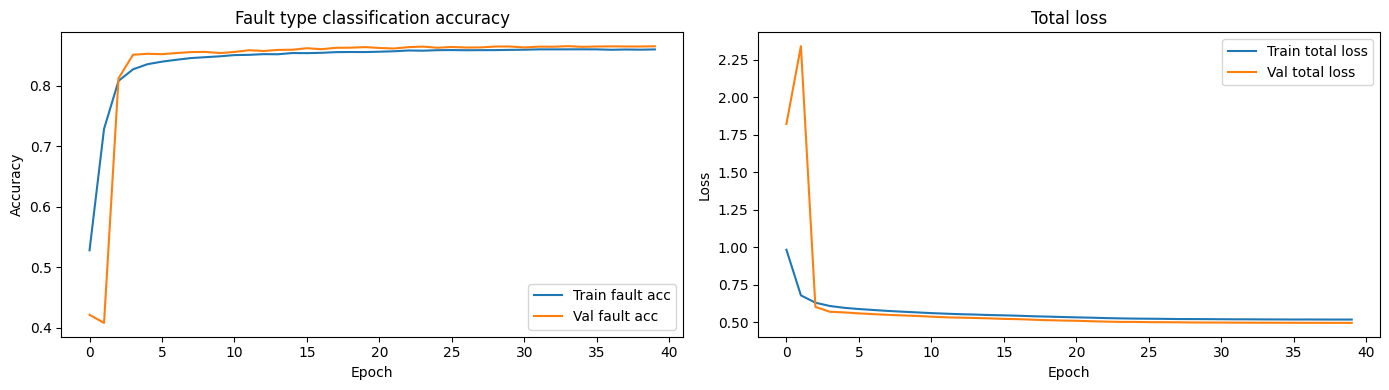

Training history plot saved.


In [71]:
# CELL 14: Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['fault_type_accuracy'], label='Train fault acc')
axes[0].plot(history.history['val_fault_type_accuracy'], label='Val fault acc')
axes[0].set_title('Fault type classification accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train total loss')
axes[1].plot(history.history['val_loss'], label='Val total loss')
axes[1].set_title('Total loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'training_history.png'), dpi=150)
plt.show()
print("Training history plot saved.")

In [72]:
# CELL 15: Evaluate on test set
results = model.evaluate(
    x={'string_input': X_str_test, 'meta_input': X_meta_test},
    y={'fault_type': y_fault_test, 'string_localization': y_str_test},
    batch_size=256,
    verbose=0
)

print("Test total loss:                  ", round(results[0], 4))
print("Test fault type accuracy:         ", round(results[3], 4))
print("Test string localization accuracy:", round(results[4], 4))

Test total loss:                   0.4966
Test fault type accuracy:          0.8651
Test string localization accuracy: 0.7893


Fault Type Classification Report:
               precision    recall  f1-score   support

       Normal       0.73      0.91      0.81      7500
 Open Circuit       0.99      0.89      0.94      7500
Short Circuit       0.90      0.99      0.94      7500
    Shadowing       0.88      0.67      0.76      7500

     accuracy                           0.87     30000
    macro avg       0.88      0.87      0.86     30000
 weighted avg       0.88      0.87      0.86     30000



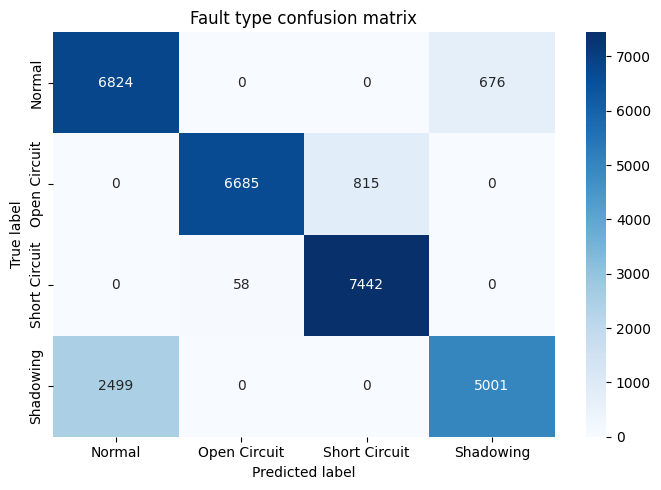

In [73]:
# CELL 16: Detailed classification report for fault type head
y_fault_pred_probs, y_str_pred_probs = model.predict(
    {'string_input': X_str_test, 'meta_input': X_meta_test},
    batch_size=256,
    verbose=0
)

y_fault_pred = np.argmax(y_fault_pred_probs, axis=1)
y_fault_true = np.argmax(y_fault_test, axis=1)

FAULT_NAMES = ['Normal', 'Open Circuit', 'Short Circuit', 'Shadowing']

print("Fault Type Classification Report:")
print(classification_report(y_fault_true, y_fault_pred, target_names=FAULT_NAMES))

cm = confusion_matrix(y_fault_true, y_fault_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=FAULT_NAMES, yticklabels=FAULT_NAMES, cmap='Blues')
plt.title('Fault type confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

In [79]:
# CELL 17: String localization performance
STRING_THRESHOLD = 0.5

y_str_pred_bin = (y_str_pred_probs >= STRING_THRESHOLD).astype(int)

# Compute exact match ratio (all strings correctly predicted for a sample)
exact_match = np.all(y_str_pred_bin == y_str_test.astype(int), axis=1).mean()

# Per-string precision, recall, F1
from sklearn.metrics import f1_score, precision_score, recall_score

f1  = f1_score(y_str_test.astype(int), y_str_pred_bin, average='macro', zero_division=0)
prec = precision_score(y_str_test.astype(int), y_str_pred_bin, average='macro', zero_division=0)
rec  = recall_score(y_str_test.astype(int), y_str_pred_bin, average='macro', zero_division=0)

print("String Localization Performance:")
print(f"  Exact match ratio : {exact_match:.4f}")
print(f"  Macro F1 score    : {f1:.4f}")
print(f"  Macro Precision   : {prec:.4f}")
print(f"  Macro Recall      : {rec:.4f}")

String Localization Performance:
  Exact match ratio : 0.7510
  Macro F1 score    : 0.0000
  Macro Precision   : 0.0000
  Macro Recall      : 0.0000


In [80]:
# CELL 18: Inference function
def predict_fault_location(raw_reading_dict, model, scaler_string, scaler_meta,
                            string_threshold=0.5):
    """
    Given a single inverter reading as a dict with keys matching ALL_FEATURE_COLS,
    returns the fault type and which strings are faulty.

    Parameters
    ----------
    raw_reading_dict : dict
        Keys are column names (Vstr1(V), ..., Istr32(A), Ppv(W), ...)
        Values are float readings from the inverter.
    model : Keras model
    scaler_string : fitted MinMaxScaler for the 64 string features
    scaler_meta : fitted MinMaxScaler for the 6 meta features
    string_threshold : float, default 0.5

    Returns
    -------
    dict with keys:
        'fault_type'      : int (0-3)
        'fault_name'      : str
        'faulty_strings'  : list of int (1-indexed string numbers)
        'string_probs'    : dict of string_number -> probability
    """
    V_COLS_LOCAL  = [f'Vstr{i}(V)' for i in range(1, 33)]
    I_COLS_LOCAL  = [f'Istr{i}(A)' for i in range(1, 33)]
    META_COLS_LOCAL = ['Ppv(W)', 'INVTemp(℃)', 'AMTemp1(℃)', 'BTTemp(℃)',
                       'OUTTemp(℃)', 'AMTemp2(℃)']

    v_vals    = np.array([raw_reading_dict[c] for c in V_COLS_LOCAL], dtype=np.float32)
    i_vals    = np.array([raw_reading_dict[c] for c in I_COLS_LOCAL], dtype=np.float32)
    meta_vals = np.array([raw_reading_dict[c] for c in META_COLS_LOCAL], dtype=np.float32)

    string_raw = np.concatenate([v_vals, i_vals]).reshape(1, -1)
    meta_raw   = meta_vals.reshape(1, -1)

    string_scaled = scaler_string.transform(string_raw)
    meta_scaled   = scaler_meta.transform(meta_raw)

    string_3d = np.zeros((1, 32, 2), dtype=np.float32)
    for idx in range(32):
        string_3d[0, idx, 0] = string_scaled[0, idx]
        string_3d[0, idx, 1] = string_scaled[0, idx + 32]

    fault_probs, str_probs = model.predict(
        {'string_input': string_3d, 'meta_input': meta_scaled},
        verbose=0
    )

    fault_type = int(np.argmax(fault_probs[0]))
    fault_name = ['Normal', 'Open Circuit', 'Short Circuit', 'Shadowing'][fault_type]

    faulty_strings = [s + 1 for s in range(32) if str_probs[0, s] >= string_threshold]

    string_prob_dict = {s + 1: round(float(str_probs[0, s]), 4) for s in range(32)}

    return {
        'fault_type':     fault_type,
        'fault_name':     fault_name,
        'faulty_strings': faulty_strings,
        'string_probs':   string_prob_dict
    }


# Example usage with a dummy reading
dummy_reading = {col: float(df_clean[col].median()) for col in ALL_FEATURE_COLS}
result = predict_fault_location(dummy_reading, model, scaler_string, scaler_meta)

print("Example inference result:")
print("  Fault type     :", result['fault_type'], "-", result['fault_name'])
print("  Faulty strings :", result['faulty_strings'])

Example inference result:
  Fault type     : 0 - Normal
  Faulty strings : []


In [81]:
# CELL 19: Save the scalers to Drive (needed for inference later)
import pickle

with open(os.path.join(DRIVE_SAVE_PATH, 'scaler_string.pkl'), 'wb') as f:
    pickle.dump(scaler_string, f)

with open(os.path.join(DRIVE_SAVE_PATH, 'scaler_meta.pkl'), 'wb') as f:
    pickle.dump(scaler_meta, f)

print("Scalers saved to Drive.")
print("All artifacts saved:")
print("  Model  :", MODEL_SAVE_PATH)
print("  Synth  :", SYNTH_SAVE_PATH)
print("  Scalers: scaler_string.pkl, scaler_meta.pkl")
print("  Plots  : training_history.png, confusion_matrix.png")

Scalers saved to Drive.
All artifacts saved:
  Model  : /content/drive/MyDrive/Fault Localization/best_cnn_lstm_model.keras
  Synth  : /content/drive/MyDrive/Fault Localization/synthetic_fault_data.xlsx
  Scalers: scaler_string.pkl, scaler_meta.pkl
  Plots  : training_history.png, confusion_matrix.png


In [82]:
# CELL 21 (NEW): Manual test cases to verify the model works correctly
print("Running manual test cases...\n")

def make_test_reading(fault_type, faulty_string_indices):
    """
    Build a realistic inverter reading with a known ground truth.
    faulty_string_indices: list of 0-indexed strings to inject fault into.
    Returns a dict matching ALL_FEATURE_COLS.
    """
    v = V_MEAN.copy().astype(float)
    i = I_MEAN.copy().astype(float)

    # Add small normal noise to all strings first
    v += np.random.normal(0, 8, N_STRINGS)
    i += np.random.normal(0, 0.3, N_STRINGS)
    v = np.clip(v, 0, None)
    i = np.clip(i, 0, None)

    if fault_type == 1:   # open circuit
        for idx in faulty_string_indices:
            v[idx] = V_MEAN[idx] * 1.18
            i[idx] = 0.02

    elif fault_type == 2:  # short circuit
        for idx in faulty_string_indices:
            v[idx] = 5.0
            i[idx] = I_MEAN[idx] * 1.22

    elif fault_type == 3:  # shadowing
        for idx in faulty_string_indices:
            v[idx] *= 0.55
            i[idx] *= 0.55

    reading = {}
    for idx, col in enumerate(V_COLS):
        reading[col] = float(v[idx])
    for idx, col in enumerate(I_COLS):
        reading[col] = float(i[idx])
    reading['Ppv(W)']     = float(np.sum(v * i))
    reading['INVTemp(℃)'] = float(META_MEAN[1])
    reading['AMTemp1(℃)'] = float(META_MEAN[2])
    reading['BTTemp(℃)']  = float(META_MEAN[3])
    reading['OUTTemp(℃)'] = float(META_MEAN[4])
    reading['AMTemp2(℃)'] = float(META_MEAN[5])

    return reading

FAULT_NAMES = ['Normal', 'Open Circuit', 'Short Circuit', 'Shadowing']

test_cases = [
    # (description, fault_type, faulty_string_0indexed, expected_strings_1indexed)
    ("Normal operation, no faults",               0, [],          []),
    ("Open circuit on string 5",                  1, [4],         [5]),
    ("Open circuit on strings 3 and 17",          1, [2, 16],     [3, 17]),
    ("Short circuit on string 10",                2, [9],         [10]),
    ("Short circuit on strings 1, 20, 28",        2, [0, 19, 27], [1, 20, 28]),
    ("Shadowing on string 7",                     3, [6],         [7]),
    ("Shadowing on strings 4, 8, 15, 22",         3, [3, 7, 14, 21], [4, 8, 15, 22]),
]

STRING_THRESHOLD = 0.10
all_passed = True

for desc, ft, faulty_0idx, expected_strings in test_cases:
    reading = make_test_reading(ft, faulty_0idx)
    result  = predict_fault_location(reading, model, scaler_string, scaler_meta,
                                     string_threshold=STRING_THRESHOLD)

    fault_correct  = result['fault_type'] == ft
    pred_set       = set(result['faulty_strings'])
    exp_set        = set(expected_strings)
    strings_correct = pred_set == exp_set

    status = "PASS" if (fault_correct and strings_correct) else "FAIL"
    if status == "FAIL":
        all_passed = False

    print(f"[{status}] {desc}")
    print(f"       Expected fault : {ft} ({FAULT_NAMES[ft]})")
    print(f"       Predicted fault: {result['fault_type']} ({result['fault_name']})")
    print(f"       Expected strings : {sorted(expected_strings)}")
    print(f"       Predicted strings: {sorted(result['faulty_strings'])}")

    # Show top suspicious strings by probability even if threshold missed them
    top_probs = sorted(result['string_probs'].items(), key=lambda x: x[1], reverse=True)[:6]
    print(f"       Top string probs : { {k: v for k,v in top_probs} }")
    print()

if all_passed:
    print("All test cases passed.")
else:
    print("Some test cases failed. Check probabilities above — if the right strings")
    print("are scoring high but below 0.5, lower STRING_THRESHOLD to 0.3 and rerun.")

Running manual test cases...

[FAIL] Normal operation, no faults
       Expected fault : 0 (Normal)
       Predicted fault: 1 (Open Circuit)
       Expected strings : []
       Predicted strings: [5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
       Top string probs : {6: 0.2503, 5: 0.2193, 12: 0.1873, 11: 0.1857, 25: 0.1753, 24: 0.1689}

[FAIL] Open circuit on string 5
       Expected fault : 1 (Open Circuit)
       Predicted fault: 1 (Open Circuit)
       Expected strings : [5]
       Predicted strings: [5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
       Top string probs : {12: 0.2164, 13: 0.2144, 11: 0.1976, 15: 0.1976, 14: 0.1963, 25: 0.1895}

[FAIL] Open circuit on strings 3 and 17
       Expected fault : 1 (Open Circuit)
       Predicted fault: 1 (Open Circuit)
       Expected strings : [3, 17]
       Predicted strings: [5, 6, 9, 10, 11, 12, 13, 14, 22, 23, 24, 25, 26, 

Best threshold for string localization: 0.10
Best macro F1 at that threshold       : 0.0000


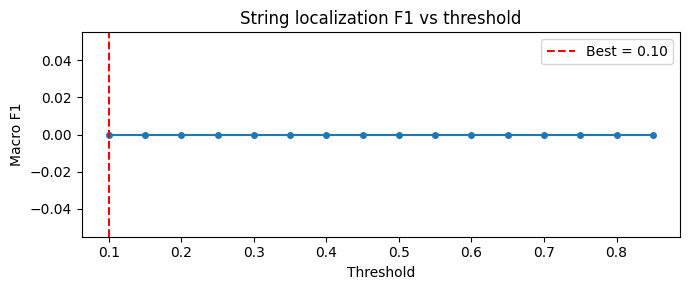


Use STRING_THRESHOLD = 0.10 in predict_fault_location()


In [83]:
# CELL 22 (NEW): Threshold tuning — find best threshold on the validation set
from sklearn.metrics import f1_score

_, y_str_val_pred = model.predict(
    {'string_input': X_str_val, 'meta_input': X_meta_val},
    batch_size=512, verbose=0
)

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = []

for thresh in thresholds:
    preds = (y_str_val_pred >= thresh).astype(int)
    f1 = f1_score(y_str_val.astype(int), preds, average='macro', zero_division=0)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f"Best threshold for string localization: {best_thresh:.2f}")
print(f"Best macro F1 at that threshold       : {best_f1:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(thresholds, f1_scores, marker='o', markersize=4)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1')
plt.title('String localization F1 vs threshold')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'threshold_tuning.png'), dpi=150)
plt.show()

print(f"\nUse STRING_THRESHOLD = {best_thresh:.2f} in predict_fault_location()")

In [84]:
# Uncomment and run this cell when you want to reload without retraining

# import pickle
# from tensorflow import keras
#
# model = keras.models.load_model(
#     '/content/drive/MyDrive/SolarProject/best_cnn_lstm_model.keras'
# )
#
# with open('/content/drive/MyDrive/SolarProject/scaler_string.pkl', 'rb') as f:
#     scaler_string = pickle.load(f)
#
# with open('/content/drive/MyDrive/SolarProject/scaler_meta.pkl', 'rb') as f:
#     scaler_meta = pickle.load(f)
#
# print("Model and scalers loaded.")

In [85]:
# CELL 23 (NEW): How the model reads data — explanation in code form
print("Model input shape (string branch):", model.input[0].shape)
print("Model input shape (meta branch):  ", model.input[1].shape)
print("Fault type output shape:          ", model.output[0].shape)
print("String localization output shape: ", model.output[1].shape)
print()
print("Each position in the sequence = one string")
print("Position 0 = String 1, Position 31 = String 32")

Model input shape (string branch): (None, 32, 2)
Model input shape (meta branch):   (None, 6)
Fault type output shape:           (None, 4)
String localization output shape:  (None, 32)

Each position in the sequence = one string
Position 0 = String 1, Position 31 = String 32


Generating 200 test readings with open circuit faults...

Total test readings: 200
  Normal readings      : 50
  Open circuit readings: 150

Fault type accuracy: 118/200 = 59.0%
String exact match : 45/200 = 22.5%

First 20 readings detail:
#     True fault      Pred fault      True strings           Pred strings           Match
-----------------------------------------------------------------------------------------------
0     Normal          Normal          []                     []                     OK
1     Normal          Normal          []                     []                     OK
2     Normal          Shadow          []                     []                     X
3     Normal          Normal          []                     []                     OK
4     Normal          Normal          []                     []                     OK
5     Normal          Shadow          []                     []                     X
6     Normal          Normal          []             

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SolarProject/test_dataset_results.png'

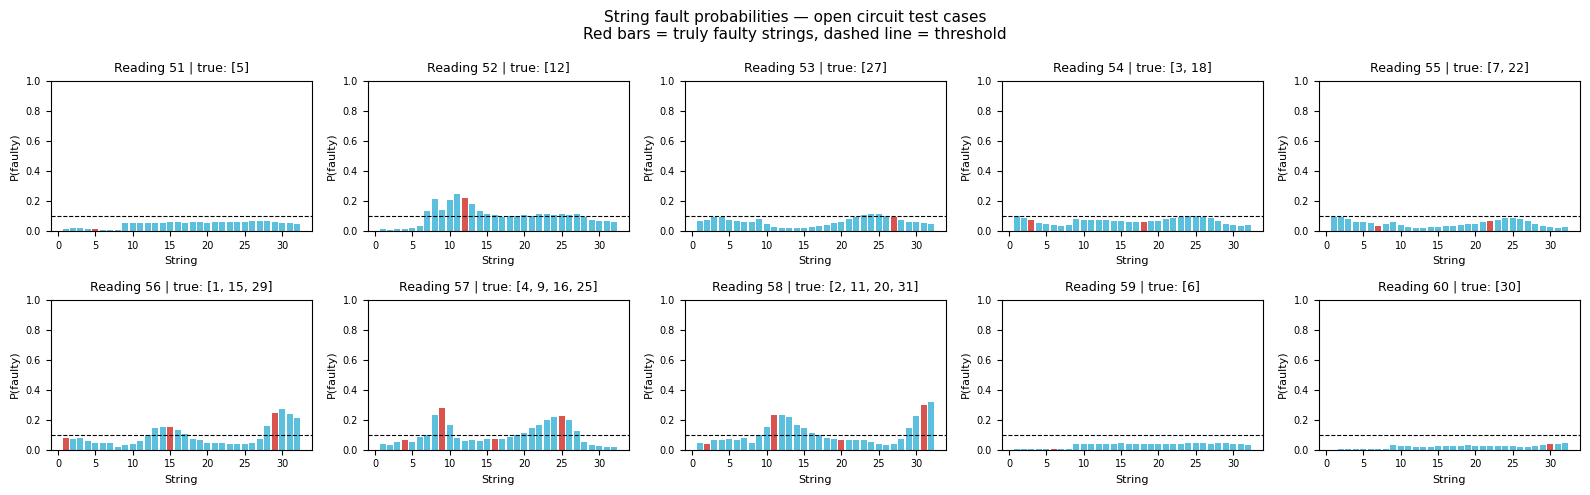

In [87]:
# CELL 24 (NEW): Sample test dataset — 200 readings, one fault type (open circuit)
print("Generating 200 test readings with open circuit faults...\n")

# Ground truth list: (reading_index, faulty_strings_1indexed)
test_readings   = []
ground_truth_ft = []    # fault type per reading
ground_truth_st = []    # faulty strings per reading (1-indexed)

# 50 normal readings as control
for _ in range(50):
    v = np.clip(np.random.normal(V_MEAN, V_STD + 1e-6), 0, None)
    i = np.clip(np.random.normal(I_MEAN, I_STD + 1e-6), 0, None)
    reading = dict(zip(V_COLS, v.tolist()))
    reading.update(dict(zip(I_COLS, i.tolist())))
    reading['Ppv(W)']     = float(np.sum(v * i))
    reading['INVTemp(℃)'] = float(META_MEAN[1])
    reading['AMTemp1(℃)'] = float(META_MEAN[2])
    reading['BTTemp(℃)']  = float(META_MEAN[3])
    reading['OUTTemp(℃)'] = float(META_MEAN[4])
    reading['AMTemp2(℃)'] = float(META_MEAN[5])
    test_readings.append(reading)
    ground_truth_ft.append(0)
    ground_truth_st.append([])

# 150 open circuit readings with different combinations of faulty strings
fault_combinations = [
    [5],
    [12],
    [27],
    [3, 18],
    [7, 22],
    [1, 15, 29],
    [4, 9, 16, 25],
    [2, 11, 20, 31],
    [6],
    [30],
]

for i in range(150):
    combo = fault_combinations[i % len(fault_combinations)]
    v = np.clip(np.random.normal(V_MEAN, V_STD + 1e-6), 0, None)
    ic = np.clip(np.random.normal(I_MEAN, I_STD + 1e-6), 0, None)
    irr = random.uniform(0.88, 1.0)
    v *= irr
    ic *= irr

    for s in combo:                        # s is 1-indexed
        v[s - 1]  = V_MEAN[s - 1] * random.uniform(1.10, 1.22)
        ic[s - 1] = random.uniform(0.0, 0.08)

    reading = dict(zip(V_COLS, v.tolist()))
    reading.update(dict(zip(I_COLS, ic.tolist())))
    reading['Ppv(W)']     = float(np.sum(v * ic))
    reading['INVTemp(℃)'] = float(META_MEAN[1] + np.random.normal(0, 1))
    reading['AMTemp1(℃)'] = float(META_MEAN[2] + np.random.normal(0, 1))
    reading['BTTemp(℃)']  = float(META_MEAN[3] + np.random.normal(0, 1))
    reading['OUTTemp(℃)'] = float(META_MEAN[4])
    reading['AMTemp2(℃)'] = float(META_MEAN[5])
    test_readings.append(reading)
    ground_truth_ft.append(1)
    ground_truth_st.append(combo)

print(f"Total test readings: {len(test_readings)}")
print(f"  Normal readings      : 50")
print(f"  Open circuit readings: 150")

# Run all 200 through the model
BEST_THRESH = 0.10    # use the best threshold found in Cell 22

results_ft = []
results_st = []

for reading in test_readings:
    r = predict_fault_location(reading, model, scaler_string, scaler_meta,
                               string_threshold=BEST_THRESH)
    results_ft.append(r['fault_type'])
    results_st.append(set(r['faulty_strings']))

# Evaluate fault type accuracy
ft_correct = sum(p == g for p, g in zip(results_ft, ground_truth_ft))
print(f"\nFault type accuracy: {ft_correct}/200 = {ft_correct/200:.1%}")

# Evaluate string localization (exact match)
st_correct = sum(set(p) == set(g) for p, g in zip(results_st, ground_truth_st))
print(f"String exact match : {st_correct}/200 = {st_correct/200:.1%}")

# Per-reading breakdown for the first 20
print("\nFirst 20 readings detail:")
print(f"{'#':<5} {'True fault':<15} {'Pred fault':<15} {'True strings':<22} {'Pred strings':<22} {'Match'}")
print("-" * 95)

FAULT_NAMES = ['Normal', 'Open Ckt', 'Short Ckt', 'Shadow']

for idx in range(20):
    tf_name = FAULT_NAMES[ground_truth_ft[idx]]
    pf_name = FAULT_NAMES[results_ft[idx]]
    ts = str(sorted(ground_truth_st[idx]))
    ps = str(sorted(list(results_st[idx])))
    match = "OK" if (results_ft[idx] == ground_truth_ft[idx] and
                     results_st[idx] == set(ground_truth_st[idx])) else "X"
    print(f"{idx:<5} {tf_name:<15} {pf_name:<15} {ts:<22} {ps:<22} {match}")

# Show string probability heatmap for 10 open circuit readings
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
axes = axes.flatten()

oc_indices = [i for i, ft in enumerate(ground_truth_ft) if ft == 1][:10]

for plot_idx, data_idx in enumerate(oc_indices):
    reading = test_readings[data_idx]
    r = predict_fault_location(reading, model, scaler_string, scaler_meta,
                               string_threshold=BEST_THRESH)
    probs = [r['string_probs'][s+1] for s in range(32)]
    true_faulty = [s - 1 for s in ground_truth_st[data_idx]]

    colors = ['#d9534f' if i in true_faulty else '#5bc0de' for i in range(32)]
    axes[plot_idx].bar(range(1, 33), probs, color=colors, width=0.8)
    axes[plot_idx].axhline(BEST_THRESH, color='black', linestyle='--', linewidth=0.8)
    axes[plot_idx].set_title(f"Reading {data_idx+1} | true: {sorted(ground_truth_st[data_idx])}", fontsize=9)
    axes[plot_idx].set_xlabel('String', fontsize=8)
    axes[plot_idx].set_ylabel('P(faulty)', fontsize=8)
    axes[plot_idx].set_ylim(0, 1)
    axes[plot_idx].tick_params(labelsize=7)

fig.suptitle('String fault probabilities — open circuit test cases\nRed bars = truly faulty strings, dashed line = threshold', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SolarProject/test_dataset_results.png', dpi=150)
plt.show()
print("Plot saved.")